# A simple trading rule
As systematic traders we believe that the future will be at least a bit like the past. So first of all we need some past data. In principle past data can come from many places, but to begin with we'll get it from some pre-baked CSV files:

In [3]:
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
data = csvFuturesSimData()
data

Configuring sim logging


csvFuturesSimData object with 252 instruments

What instruments have we got?

In [4]:
data.get_instrument_list()

['FTSECHINAH',
 'EU-MID',
 'EU-DIV30',
 'JP-REALESTATE',
 'SMI',
 'DJSTX-SMALL',
 'LUMBER-new',
 'EUROSTX200-LARGE',
 'CAD5',
 'PALLAD',
 'HIGHYIELD',
 'GBPEUR',
 'SP500_micro',
 'BOVESPA',
 'IRON',
 'LEANHOG',
 'GAS-LAST',
 'US-STAPLES',
 'ETHER-micro',
 'WHEAT_ICE',
 'VNKI',
 'SOYBEAN',
 'EU-DJ-UTIL',
 'FTSEINDO',
 'NZD',
 'ETHANOL',
 'GOLD',
 'MSCIASIA',
 'BB3M',
 'CAD2',
 'EU-DJ-TECH',
 'JPY_mini',
 'EU-TECH',
 'MIB',
 'SMI-MID',
 'GILT',
 'BTP',
 'EU-TRAVEL',
 'MSCIWORLD',
 'SWISSLEAD',
 'SOYBEAN_mini',
 'KRWUSD_mini',
 'STEEL',
 'HANGTECH',
 'NASDAQ_micro',
 'ROBUSTA',
 'VIX_mini',
 'CAD10',
 'AEX',
 'BBCOMM',
 'NASDAQ',
 'EU-HOUSE',
 'HOUSE-US',
 'NIKKEI400',
 'RUSSELL',
 'GASOILINE_micro',
 'EURIBOR-ICE',
 'CANOLA',
 'EU-HEALTH',
 'HEATOIL-ICE',
 'MSCIEAFA',
 'SUGAR16',
 'SILVER',
 'EUA',
 'COPPER-micro',
 'CHEESE',
 'CAD_micro',
 'EURCHF',
 'GAS-PEN',
 'MILKWET',
 'CAC',
 'CHF_micro',
 'GASOIL',
 'AUD',
 'EU-CHEM',
 'EU-DJ-OIL',
 'BUND',
 'EU-FOOD',
 'US-MATERIAL',
 'US10',
 '

`data` objects behave a bit like dicts (though they don't formally inherit from them), so you can access data inside `data` much like you would a dict:

In [5]:
# get the instrument list
data.keys()

# get instrument prices on a specific instrument
data['SP500_micro']

index
1982-09-14 23:00:00     679.40
1982-09-15 23:00:00     679.90
1982-09-16 23:00:00     679.25
1982-09-17 23:00:00     678.35
1982-09-20 23:00:00     679.15
                        ...   
2024-03-28 17:00:00    5309.25
2024-03-28 18:00:00    5316.50
2024-03-28 19:00:00    5305.50
2024-03-28 20:00:00    5306.00
2024-03-28 23:00:00    5303.75
Name: price, Length: 35898, dtype: float64

For futures data, we can even get the carry contract data we'd need for the carry rule:

In [6]:
data.get_instrument_raw_carry_data('VIX').tail(6)

,PRICE,CARRY,PRICE_CONTRACT,CARRY_CONTRACT
index,,,,
2024-03-27 16:00:00,15.95,15.20,20240600,20240500
2024-03-27 17:00:00,16.05,15.20,20240600,20240500
2024-03-27 18:00:00,16.00,15.20,20240600,20240500
2024-03-27 19:00:00,16.00,15.15,20240600,20240500
2024-03-27 20:00:00,16.00,15.15,20240600,20240500
2024-03-27 23:00:00,16.00,15.15,20240600,20240500


## A simple trading rule
This will essentially be redundant, but it can give us a flavor of how to use the tools at hand to roll our own trading rules.

In [7]:
# create a simple ewmac trading rule
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc


def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    Calculate the ewmac trading rule forecast, given a price and EWMA speeds Lfast, Lslow and vol_lookback

    """
    ## price: This is the stitched price series
    ## We can't use the price of the contract we're trading, or the volatility will be jumpy
    ## And we'll miss out on the rolldown. See https://qoppac.blogspot.com/2015/05/systems-building-futures-rolling.html

    price = price.resample("1B").last()
    if Lslow is None:
        Lslow = 4 * Lfast

    ## We don't need to calculate the decay parameter, just use the span directly

    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma

    vol = robust_vol_calc(price.diff())

    return raw_ewmac / vol


Let's run this and look at the output:

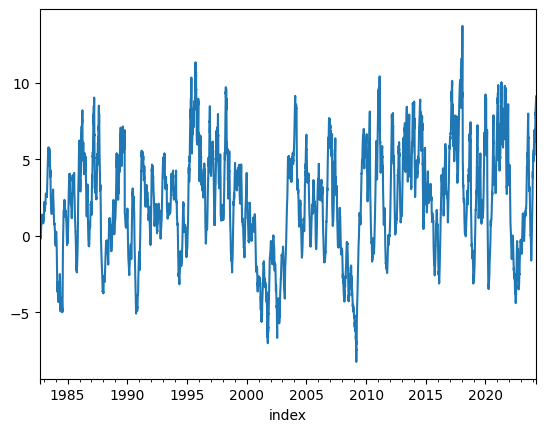

In [8]:
instrument_code='SP500'
price=data.daily_prices(instrument_code)
ewmac=calc_ewmac_forecast(price, 32, 128)
ewmac.tail(5)

from matplotlib.pyplot import show
ewmac.plot()
show()

We can see if our strategies make any money through the `account_forecast` package:

In [9]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast = ewmac, price=price)
account.percent.stats()

[[('min', '-8.484'),
  ('max', '5.222'),
  ('median', '0.00113'),
  ('mean', '0.007455'),
  ('std', '0.4738'),
  ('skew', '-1.475'),
  ('ann_mean', '1.908'),
  ('ann_std', '7.58'),
  ('sharpe', '0.2518'),
  ('sortino', '0.2692'),
  ('avg_drawdown', '-9.164'),
  ('time_in_drawdown', '0.9823'),
  ('calmar', '0.08002'),
  ('avg_return_to_drawdown', '0.2083'),
  ('avg_loss', '-0.2802'),
  ('avg_gain', '0.2685'),
  ('gaintolossratio', '0.9585'),
  ('profitfactor', '1.058'),
  ('hitrate', '0.5247'),
  ('t_stat', '1.638'),
  ('p_value', '0.1014')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

We can also access strategy reporting functions from the syscore package container, because the `account` inherits from a pandas dataframe.

<Axes: xlabel='index'>

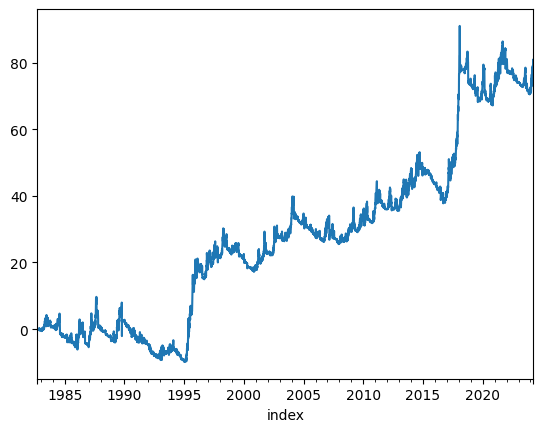

In [10]:
import syscore.pandas.strategy_functions

account.sharpe()  ## get the Sharpe Ratio (annualised), and any other statistic which is in the stats list
account.curve().plot()  ## plot the cumulative account curve (equivalent to account.cumsum().plot() inicidentally)
# account.percent  ## gives a % curve
# syscore.pandas.strategy_functions.drawdown().plot()  ## see the drawdowns as a percentage
# account.weekly  ## weekly returns (also daily [default], monthly, annual)
# account.gross.ann_mean()  ## annual mean for gross returns, also costs (there are none in this simple example)

# A simple system
Yeah, that's cool and all, but we want to do more than just roll our own trading rule and test it. We wanna build a whole trading *system* comprising several trading rules and multiple instruments. 

### What Makes a System?
A system consists of some `data` (which we previewed in the first few cells above), a number of processing *stages*, and optionally a configuration to modify how each of the stages behaves.

Here's a full list of the processing stages to go from 0 --> system:
1. Preprocessing some raw data (out of the scope of this intro)
2. Running some trading rules over it to generate forecasts
3. Scaling and capping those forecasts
4. Combining forecasts together
5. Position sizing
6. Creating a portfolio of instruments
7. Working out the P&L

For now, we'll just build a simple system with an out-of-the-box rule.

In [11]:
# get our data
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
data = csvFuturesSimData()

# pull an ewmac rule off the shelf
from systems.provided.rules.ewmac import ewmac_forecast_with_defaults as ewmac
from systems.forecasting import Rules

# instantiate the rule
my_rules=Rules(ewmac)

# take a look at it
my_rules.trading_rules()

{'rule0': TradingRule; function: <function ewmac_forecast_with_defaults at 0x10c1e28e0>, data: data.daily_prices (args: {}) and other_args: }

`rule0` is not a great name for a rule, and the info stored here on the rule is pretty ambiguous. We can fix this by leveraging the fact that `Rules()` objects accept a dict. 

In [12]:
my_rules = Rules(
    dict(ewmac_default=ewmac)
)

my_rules.trading_rules()

{'ewmac_default': TradingRule; function: <function ewmac_forecast_with_defaults at 0x10c1e28e0>, data: data.daily_prices (args: {}) and other_args: }

Now that we have a rule, we need to place it in a system that incorporates what we have so far. This is the implementation of the `rules_stage`:

In [13]:
from systems.basesystem import System
my_system = System(
    [
        my_rules
    ],  data
)

my_system

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode


System base_system with .config, .data, and .stages: rules

Now, let's get some forecasts. We can do this by accessing our system's rules object's `get_raw_forecast()` method and passing it the instrument and the rule id we want.

In [14]:
my_system.rules.get_raw_forecast('SP500', 'ewmac_default').tail(5)

2025-11-04 05:55:57 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-11-04 05:55:57 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-11-04 05:55:57 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-11-04 05:55:57 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SP500'} Calculating raw forecast SP500 for ewmac_default


index
2024-03-22    2.004708
2024-03-25    2.019601
2024-03-26    2.040437
2024-03-27    2.046548
2024-03-28    2.059007
Freq: B, Name: price, dtype: float64

This is the main pattern of the system building process: `my_system...stage_name...get_something()`. The `Rules` object have become an attribute of the parent system with the name `rules`. The names used for each stage are fixed regardless of exactly what the stage class or instance is called. This means we can always find what we need.

Now, what about the more usual case when we want more than one trading rule? To define multiple flavors of a given trading rule, we need to learn a bit more about trading rules. The initial way of creating a trading rule (`my_rules=Rules(dict(ewmac_default=ewmac))`) has an easier equivalent in the `TradingRule` object.

What is a `TradingRule`? A TradingRule contains 3 elements - a function, a list of any data the function needs, and a dict of any other arguments that can be passed to the function. So the function is just the ewmac function that we imported earlier, and in this trivial case there is no data, and no arguments. Having no data is fine, because the code assumes that you'd normally want to pass the price of an instrument to a trading rule if you don't tell it otherwise. Furthermore, on this occasion having no arguments is also no problem since the ewmac function we're using includes some defaults.

If you're familiar with the concept in Python of args and kwargs; data is a bit like args - we always pass a list of positional arguments to function; and other_args are a bit like kwargs - we always pass in a dict of named arguments to function

There are a few different ways to define trading rules completely. I'll use a couple of different ones here:

In [15]:
from systems.trading_rules import TradingRule

# The different ways we can create variations on a given trading rule using the TradingRule object

# Ex: Passing a TradingRule's elements as a tuple in order (fn, data, fn's inputs)
ewmac_8 = TradingRule((ewmac, [], dict(Lfast=8, Lslow=32)))

# Ex: (More verbose) Passing a TradingRule's elements through dictionaries
ewmac_32 = TradingRule(dict(
    function=ewmac,
    other_args=dict(Lfast=32, Lslow=128)
))

# Pass the rules you created into my_rules
my_trading_rules = Rules(dict(ewmac8=ewmac_8, ewmac32=ewmac_32))

# Take a look at the ewmac32 rule now stored in my_rules
my_trading_rules.trading_rules()['ewmac32']

TradingRule; function: <function ewmac_forecast_with_defaults at 0x10c1e28e0>, data: data.daily_prices (args: {}) and other_args: Lfast, Lslow

We can check if the `ewmac32` rule we just created is the same as the one we had before. We can load it into our system and inspect the raw forecast.

In [16]:
my_system = System([my_trading_rules], data)
my_system.rules.get_raw_forecast('SP500', 'ewmac32').tail(5)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-11-04 05:55:57 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-11-04 05:55:57 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-11-04 05:55:57 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-11-04 05:55:57 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SP500'} Calculating raw forecast SP500 for ewmac32


index
2024-03-22    2.004708
2024-03-25    2.019601
2024-03-26    2.040437
2024-03-27    2.046548
2024-03-28    2.059007
Freq: B, Name: price, dtype: float64

## Config objects
A `Config` object allows us to control the behavior of the various stages in our system -- it's our knobs and levers panel. `Config` objects can be created on the fly (it's just a collection of attributes) or by reading ni files written in YAML (more on that later). To do this interactively here and now, we can follow these steps:

1. Pass in an empty `Rules()` instance
2. Create an element in `config` (called `trading_rules`) that contains our dictionary of trading rules.
3. Pass the config we created and loaded into our system. We can then access our rules through the system

For now, we'll leave the `Config()` object empty. Soon, we'll see how we can load it with configuration attributes (e.g. turn some knobs) to affect the behavior of our system-in-construction. For instance, we can pass our trading rules into our system via a `Config` object.

In [17]:
# empty config
from sysdata.config.configdata import Config

my_config = Config()
my_config

Config with elements: 

In [18]:
# using config to define our trading rules, and then accessing them in our system
empty_rules = Rules()
my_config.trading_rules = dict(ewmac8=ewmac_8, ewmac32=ewmac_32)

# import configured "empty rules"
my_new_system = System([empty_rules], data, my_config)

# take a look at the raw_forecast
my_new_system.rules.get_raw_forecast('SP500', 'ewmac32').tail(5)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-11-04 05:55:57 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-11-04 05:55:57 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-11-04 05:55:57 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-11-04 05:55:57 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SP500'} Calculating raw forecast SP500 for ewmac32


index
2024-03-22    2.004708
2024-03-25    2.019601
2024-03-26    2.040437
2024-03-27    2.046548
2024-03-28    2.059007
Freq: B, Name: price, dtype: float64

Now that we have a sense of how the config affects the system, we can extend our configuration to dial in exactly how we want to build our system without the hassle of writing a bunch of separate scripts.

The trading rules we (re)produced above aren't correctly scaled, nor do they have the cap of +/-20. We can control our system's forecast output to include forecast scalar estimation via the `Config` object. We can also configure the instruments we want to trade in the system. Note that **order doesn't matter** for the list passed to `System([...],...)`

In [20]:
from systems.forecast_scale_cap import ForecastScaleCap

# instead of pooling estimates across instruments, tell the system which instruments we want to use
my_config.instruments=['SP500', 'NASDAQ', 'US10']

# ensure we estimate a forecast scalar
my_config.use_forecast_scale_estimates = True

# add forecast scaling stage to our system
fcs = ForecastScaleCap()
my_new_system = System([fcs, empty_rules], data, my_config)

# inspect the forecast scalars
my_new_system.forecastScaleCap.get_forecast_scalar('CORN', 'ewmac32').tail(5)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-11-04 05:56:45 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-11-04 05:56:45 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-11-04 05:56:45 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-11-04 05:56:45 DEBUG base_system {'stage': 'forecastScaleCap'} Getting cross sectional forecasts for scalar calculation for ewmac32 over NASDAQ, SP500, US10
2025-11-04 05:56:45 DEBUG base_system {'stage': 'rules', 'instrument_code': 'NASDAQ'} Calculating raw forecast NASDAQ for ewmac32
2025-11-04 05:56:45 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SP500'} Calculating raw forecast SP500 for ewmac32
2025-11-04 05:56:45 DEBUG base_system {'stage': 'rules', 'instrument_code': 'US10'} Calculating raw forecast US10

index
2024-03-22    8.461910
2024-03-25    8.461356
2024-03-26    8.460789
2024-03-27    8.460218
2024-03-28    8.459639
Freq: B, dtype: float64

<Axes: xlabel='index'>

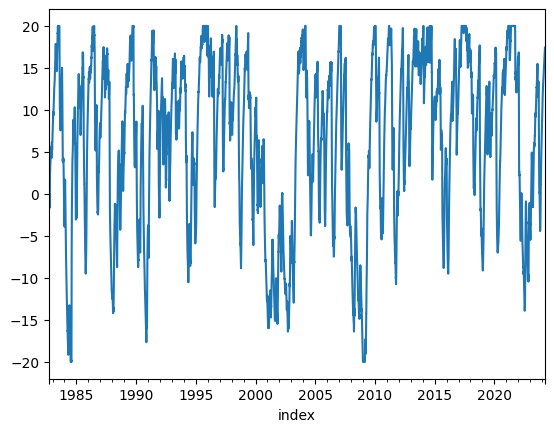

In [22]:
# inspect the capped forecast
my_new_system.forecastScaleCap.get_capped_forecast('SP500', 'ewmac32').plot()

## Combiner stage
Recall that we have two trading rule variations, so lets combine them. For now, we'll use the default behavior of equal-weighting and forecast diversification multiplier=1. 

In [ ]:
from systems.forecast_combine import ForecastCombine

combiner = ForecastCombine()
my_new_system = System([fcs, empty_rules, combiner], data, my_config)

wts = my_new_system.combForecast.get_forecast_weights('SP500').tail(5)
dm = my_new_system.combForecast.get_forecast_diversification_multiplier('SP500').tail(5)

print(wts)
print(dm)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-10-31 12:56:40 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-10-31 12:56:40 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-10-31 12:56:40 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-10-31 12:56:40 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Calculating forecast weights for SP500


2025-10-31 12:56:40 WARNING base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} You need an accounts stage in the system to estimate forecast costs for SP500 ewmac32. Using costs of zero
2025-10-31 12:56:40 WARNING base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} You need an accounts stage in the system to estimate forecast costs for SP500 ewmac8. Using costs of zero
2025-10-31 12:56:40 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Only this set of rules ['ewmac32', 'ewmac8'] is cheap enough to trade for SP500
2025-10-31 12:56:40 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Non-nested dict of forecast weights for SP500 {'ewmac8': 0.5, 'ewmac32': 0.5}: weights the same for all instruments
2025-10-31 12:56:40 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SP500'} Calculating capped forecast for SP500 ewmac32
2025-10-31 12:56:40 DEBUG base_system {'stage': 'rules', 'instrument_code': '

In [ ]:
my_new_system.combForecast.get_combined_forecast('SP500').tail(5)

2025-10-31 12:57:14 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Calculating combined forecast for SP500
2025-10-31 12:57:14 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} No mapping applied for SP500


index
2024-03-22    16.566875
2024-03-25    16.514798
2024-03-26    16.363697
2024-03-27    16.513194
2024-03-28    16.543191
Freq: B, dtype: float64

If we want to get fancy and estimate diversification multipliers and weights, we have to provide an accounts stage (using an `Accounts` object), which also requires `RawData` and `PositionSizing`.

In [ ]:
from systems.rawdata import RawData
from systems.positionsizing import PositionSizing
from systems.accounts.accounts_stage import Account

raw_data = RawData()
position_size = PositionSizing()
my_account = Account()

# using naive markowitz to get more interesting weight estimates and diversification multiplier estimates
my_config.forecast_weight_estimate = dict(method='one_period')
my_config.use_forecast_weight_estimates = True
my_config.use_forecast_div_mult_estimates = True

combiner = ForecastCombine()
my_new_system = System([fcs, empty_rules, combiner, raw_data, position_size, my_account], data, my_config)

new_wts = my_new_system.combForecast.get_forecast_weights('SP500').tail(5)
new_dm = my_new_system.combForecast.get_forecast_diversification_multiplier('SP500').tail(5)

print(new_wts)
print(new_dm)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-10-31 12:51:52 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-10-31 12:51:52 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-10-31 12:51:52 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-10-31 12:51:52 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Calculating forecast weights for SP500
2025-10-31 12:51:52 INFO base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Calculating raw forecast weights for SP500
2025-10-31 12:51:52 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'NASDAQ'} Calculating capped forecast for NASDAQ ewmac32
2025-10-31 12:51:52 DEBUG base_system {'stage': 'rules', 'instrument_code': 'NASDAQ'} Calculating raw forecast NASDAQ for ew

Those figures look a little weird, so we can use some arbitrary fixed forecast weights and diversification multipliers for now.

In [ ]:
my_config.forecast_weights=dict(ewmac8=0.5, ewmac32=0.5)
my_config.forecast_div_multiplier=1.1
my_config.use_forecast_weight_estimates = False
my_config.use_forecast_div_mult_estimates = False

my_new_system = System([fcs, empty_rules, combiner, raw_data, position_size, my_account], data, my_config)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode


In [ ]:
# inspect the combined forecast output
my_new_system.combForecast.get_combined_forecast('US10').tail(5)

2025-10-31 12:58:40 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'US10'} Calculating combined forecast for US10
2025-10-31 12:58:40 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'US10'} Calculating forecast weights for US10
2025-10-31 12:58:40 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'US10'} Calculating daily prices for US10
2025-10-31 12:58:41 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'US10'} Calculating daily prices for US10
2025-10-31 12:58:41 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'US10'} Calculating daily volatility for US10
2025-10-31 12:58:41 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'US10'} Calculating daily prices for US10
2025-10-31 12:58:41 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'US10'} Only this set of rules ['ewmac32', 'ewmac8'] is cheap enough to trade for US10
2025-10-31 12:58:41 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'US1

index
2024-03-22   -4.811169
2024-03-25   -4.697643
2024-03-26   -4.426910
2024-03-27   -3.742479
2024-03-28   -3.514240
Freq: B, dtype: float64

Now, if we provide our system with the configuration details on our risk target, our trading capital, and our base currency, we have what we need to create a full subsytem position!

In [ ]:
my_config.percentage_vol_target = 25
my_config.notional_trading_capital = 1_000_000
my_config.base_currency = 'USD'

my_new_system = System([fcs, empty_rules, combiner, raw_data, position_size, my_account], data, my_config)

my_new_system.positionSize.get_subsystem_position('SP500').tail(5)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-10-31 13:02:09 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-10-31 13:02:09 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-10-31 13:02:09 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-10-31 13:02:09 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SP500'} Calculating subsystem position for SP500
2025-10-31 13:02:09 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SP500'} Calculating volatility scalar for SP500
2025-10-31 13:02:09 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SP500'} Calculating instrument value vol for SP500
2025-10-31 13:02:09 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SP500'} Calculating instrument currency vol for S

index
2024-03-22    16.287430
2024-03-25    16.469666
2024-03-26    16.568173
2024-03-27    16.761242
2024-03-28    17.077704
Freq: B, dtype: float64

In [ ]:
from systems.portfolio import Portfolios
portfolio = Portfolios()

## Using shrinkage will speed things but - but I don't recommend it for actual trading...
my_config.use_instrument_weight_estimates = True
my_config.use_instrument_div_mult_estimates = True
my_config.instrument_weight_estimate=dict(method="shrinkage", date_method="in_sample") ## speeds things up

my_new_system = System([my_account, fcs, my_rules, combiner, position_size, raw_data,
                    portfolio], data, my_config)

print(my_new_system.portfolio.get_instrument_weights())
print(my_new_system.portfolio.get_instrument_diversification_multiplier())

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-10-31 13:03:34 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-10-31 13:03:34 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-10-31 13:03:34 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-10-31 13:03:34 INFO base_system {'stage': 'portfolio'} Calculating instrument weights
2025-10-31 13:03:34 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-10-31 13:03:34 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-10-31 13:03:34 DEBUG base_system Following instruments are marked as 'bad_markets':  ['BAD_EXAMPLE']
2025-10-31 13:03:34 DEBUG base_system Following instruments have restricted trading:  ['RESTRICTED

In [ ]:
my_new_system.portfolio.get_notional_position('SP500').tail(5)

2025-10-31 13:06:15 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SP500'} Calculating notional position for SP500
2025-10-31 13:06:15 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SP500'} No risk overlay in config: won't apply risk scaling


index
2024-03-22    6.776182
2024-03-25    6.851939
2024-03-26    6.892861
2024-03-27    6.973124
2024-03-28    7.104720
Freq: B, dtype: float64

<Axes: >

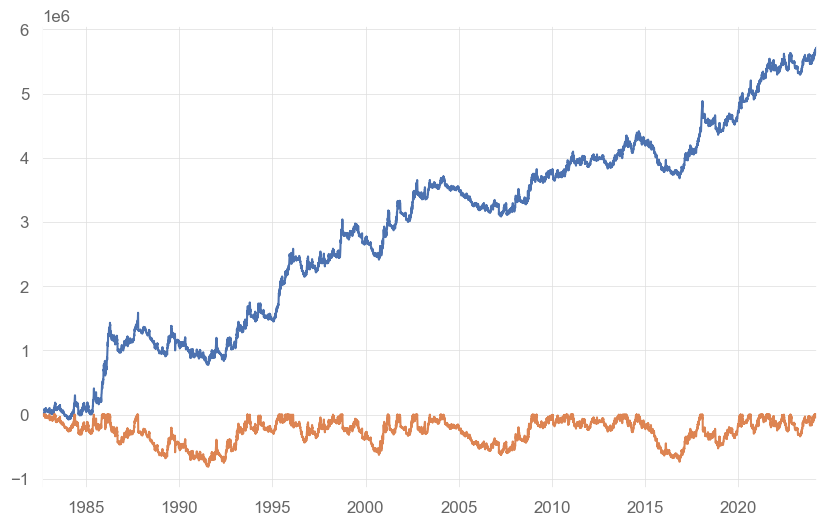

In [ ]:
profits = my_new_system.accounts.portfolio()
# profits.percent.stats()
profits.curve().plot()
profits.drawdown().plot()

In [ ]:
profits.to_frame()

,NASDAQ,SP500,US10
1982-08-30,NaN,NaN,0.000
1982-08-31,NaN,NaN,0.000
1982-09-01,NaN,NaN,0.000
1982-09-02,NaN,NaN,0.000
1982-09-03,NaN,NaN,0.000
...,...,...,...
2024-03-22,-960.0,-5325.00,-5328.125
2024-03-25,-1815.0,-2700.00,3437.500
2024-03-26,-3210.0,-2475.00,-687.500
2024-03-27,1530.0,10725.00,-2750.000
